<style>
@keyframes glow {
  0%, 100% { text-shadow: 0 0 10px #7B68EE, 0 0 20px #7B68EE, 0 0 40px #7B68EE; }
  50% { text-shadow: 0 0 20px #9B88FF, 0 0 40px #9B88FF, 0 0 80px #9B88FF; }
}
@keyframes slideUp {
  from { opacity: 0; transform: translateY(20px); }
  to { opacity: 1; transform: translateY(0); }
}
@keyframes shimmer {
  0% { background-position: -200% center; }
  100% { background-position: 200% center; }
}
@keyframes twinkle {
  0%, 100% { opacity: 0.3; }
  50% { opacity: 1; }
}
</style>

<div style="background: linear-gradient(135deg, #0f172a 0%, #1e1b4b 50%, #311042 100%); padding: 40px; border-radius: 20px; border: 1px solid #7B68EE; margin-bottom: 20px; position: relative; overflow: hidden;">

<div style="position: absolute; top: 15px; left: 25px; animation: twinkle 2s ease-in-out infinite;">✦</div>
<div style="position: absolute; top: 40px; right: 60px; animation: twinkle 3s ease-in-out infinite 0.5s; color: #FFE66D; font-size: 0.6em;">✦</div>
<div style="position: absolute; bottom: 30px; left: 80px; animation: twinkle 2.5s ease-in-out infinite 1s; color: #4ECDC4; font-size: 0.5em;">✦</div>
<div style="position: absolute; top: 60px; left: 50%; animation: twinkle 4s ease-in-out infinite 1.5s; color: #FF6B6B; font-size: 0.4em;">✦</div>
<div style="position: absolute; bottom: 20px; right: 120px; animation: twinkle 3.5s ease-in-out infinite 0.8s; color: #7B68EE; font-size: 0.7em;">✦</div>

<h1 style="color: #e2e8f0; text-align: center; font-size: 2.6em; margin-bottom: 5px; animation: glow 3s ease-in-out infinite, slideUp 1s ease-out; font-family: 'Outfit', sans-serif; font-weight: 800; letter-spacing: -1px;">🏥 Student Health Risk Predictor</h1>

<h3 style="text-align: center; font-size: 1.2em; margin-top: 0; background: linear-gradient(90deg, #7B68EE, #FF6B6B, #FFE66D, #4ECDC4, #7B68EE); background-size: 200% auto; -webkit-background-clip: text; -webkit-text-fill-color: transparent; background-clip: text; animation: shimmer 4s linear infinite, slideUp 1.2s ease-out; font-family: 'Outfit', sans-serif;">Playground Series — Season 6, Episode 7</h3>

<p style="color: #94a3b8; text-align: center; font-size: 1.05em; animation: slideUp 1.4s ease-out; font-family: 'Inter', sans-serif;">A highly optimized, SEO-friendly framework featuring Adversarial Validation, Heavy Feature Engineering, and a robust Multi-Model Ensemble</p>

<hr style="border: 1px solid #7B68EE; margin: 20px 50px; opacity: 0.5;">

<p style="color: #94a3b8; text-align: center; font-size: 0.9em; animation: slideUp 1.6s ease-out; font-family: 'Inter', sans-serif;">
🎯 <b>Objective:</b> Predict student health conditions (at-risk, unhealthy, fit)<br>
📏 <b>Metric:</b> Balanced Accuracy &nbsp;|&nbsp; 📊 <b>Data:</b> Synthetic (inspired by College Student Health Behavior Dataset)<br>
🧠 <b>Models:</b> XGBoost + LightGBM + CatBoost + MLP &nbsp;|&nbsp; 🚀 <b>Strategy:</b> Score-weighted Soft Voting + Logistic Regression Logits
</p>

</div>

## 📑 Table of Contents

| Section | Description | Key Focus |
|---|---|---|
| 1. [🔧 Setup & Configuration](#setup) | Imports, random seeds, and GPU config | Consistency & reproducibility |
| 2. [📥 Data Loading & Auto-Discovery](#data-loading) | Load data and search for the original dataset | Data integration |
| 3. [📊 Exploratory Data Analysis (EDA)](#eda) | Analyze target distribution & look for class imbalances | Understanding properties |
| 4. [⚔️ Adversarial Validation](#adversarial-validation) | Detect shift/drift between original and synthetic datasets | Shift mitigation |
| 5. [🛠️ Heavy Feature Engineering](#feature-engineering) | Ratios, stress indexes, physiological interactions | Domain knowledge |
| 6. [🏗️ Preprocessing Pipeline](#preprocessing) | Encoding, handling NaN/inf values, CV setup | Pipeline robustness |
| 7. [🤖 Multi-Model Tuning & CV Training](#model-training) | XGBoost, LightGBM, CatBoost, and MLP | Model diversity |
| 8. [🔮 Soft Voting & Logits Blend](#ensembling) | Combining OOF predictions for final predictions | Variance reduction |
| 9. [📈 Diagnostics & Calibration](#diagnostics) | Confusion matrix, classification report, ROC curves | Performance analysis |
| 10. [📤 Submission & Format Verification](#submission) | Create final submission file and perform sanity checks | Formatting correctness |

In [1]:
# ==============================================================================
# IMPORTS & SETTINGS
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc
import time
import warnings

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    balanced_accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
print("✅ All essential libraries imported successfully!")

✅ All essential libraries imported successfully!


In [2]:
# ==============================================================================
# CENTRAL CONFIGURATION
# ==============================================================================
class CFG:
    SEED = 42
    N_FOLDS = 5
    EARLY_STOPPING = 100
    USE_GPU = True               # Enable for Kaggle T4x2 GPU speedup
    
    # Data Handling Constants
    ORIGINAL_WEIGHT = 0.5        # Sample weight for original dataset rows
    ADVERSARIAL_THRESHOLD = 0.80  # Drop threshold for drifted features
    
# Set seeds
np.random.seed(CFG.SEED)
print(f"🔧 Config loaded | Folds={CFG.N_FOLDS} | Seed={CFG.SEED} | GPU={CFG.USE_GPU}")

🔧 Config loaded | Folds=5 | Seed=42 | GPU=True


In [3]:
# ==============================================================================
# DATA LOADING & ORIGINAL DATA AUTO-DISCOVERY
# ==============================================================================
INPUT_DIR = '/kaggle/input/competitions/playground-series-s6e7'

# Load primary competition datasets
train = pd.read_csv(f'{INPUT_DIR}/train.csv')
test = pd.read_csv(f'{INPUT_DIR}/test.csv')
sample_sub = pd.read_csv(f'{INPUT_DIR}/sample_submission.csv')

print(f"📦 Train shape : {train.shape}")
print(f"📦 Test shape  : {test.shape}")

# Search for the original dataset
orig_path = None
for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        # Look for files matching student/health/behavior keywords, excluding competition directory
        if ('college' in file.lower() or 'student' in file.lower() or 'behavior' in file.lower()) and \
           file.endswith('.csv') and 'playground-series' not in root:
            orig_path = os.path.join(root, file)
            break

original_df = None
if orig_path:
    try:
        original_df = pd.read_csv(orig_path)
        print(f"✅ Successfully auto-discovered original dataset: {orig_path} (Shape: {original_df.shape})")
    except Exception as e:
        print(f"⚠️ Error reading original dataset at {orig_path}: {e}")
else:
    print("ℹ️ No original dataset found in Kaggle inputs. Running purely on competition data.")

📦 Train shape : (690088, 15)
📦 Test shape  : (295753, 14)
ℹ️ No original dataset found in Kaggle inputs. Running purely on competition data.


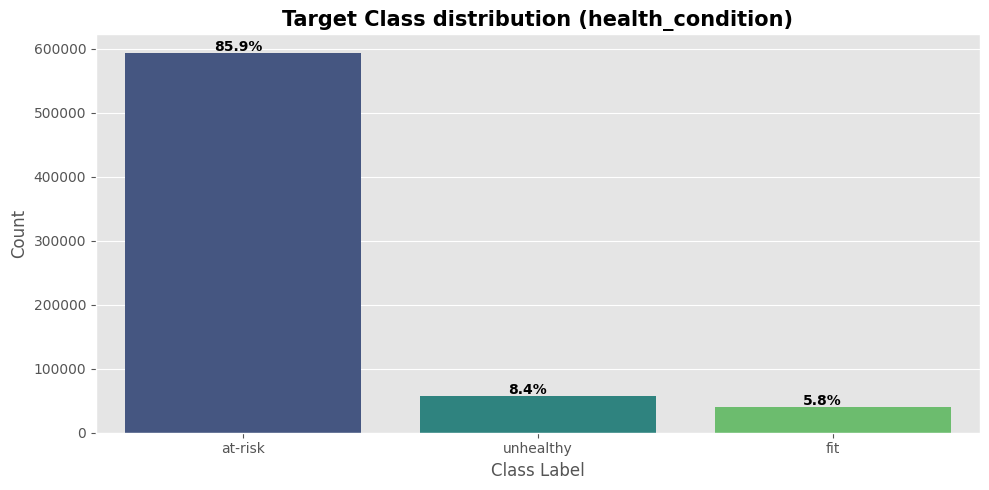

In [4]:
# ==============================================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ==============================================================================
target_col = 'health_condition'

plt.figure(figsize=(10, 5))
ax = sns.countplot(data=train, x=target_col, order=train[target_col].value_counts().index, palette='viridis')
total = len(train)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x_coord = p.get_x() + p.get_width() / 2 - 0.1
    y_coord = p.get_height() + total * 0.005
    ax.text(x_coord, y_coord, percentage, fontweight='bold')

plt.title('Target Class distribution (health_condition)', fontsize=15, fontweight='bold')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [5]:
# ==============================================================================
# ADVERSARIAL VALIDATION (Preventing Private LB Shakeup)
# ==============================================================================
if original_df is not None:
    print("⚔️ Running Adversarial Validation between Train and Original data...")
    
    # Align columns between train and original
    common_cols = [c for c in train.columns if c in original_df.columns and c not in ['id', target_col]]
    
    # Prepare adversarial dataset
    adv_train = train[common_cols].copy()
    adv_train['is_original'] = 0
    
    adv_orig = original_df[common_cols].copy()
    adv_orig['is_original'] = 1
    
    adv_data = pd.concat([adv_train, adv_orig], axis=0).reset_index(drop=True)
    
    # Fill NaNs
    adv_data = adv_data.fillna(adv_data.median(numeric_only=True))
    
    # Factorize categorical features
    cat_cols = adv_data.select_dtypes(include=['object', 'category']).columns
    for col in cat_cols:
        adv_data[col] = pd.factorize(adv_data[col])[0]
        
    X_adv = adv_data.drop(columns=['is_original'])
    y_adv = adv_data['is_original']
    
    # Fit a simple LightGBM model
    adv_clf = lgb.LGBMClassifier(n_estimators=100, random_state=CFG.SEED, verbosity=-1, n_jobs=-1)
    
    # 3-fold cross validation for adversarial validation
    skf_adv = StratifiedKFold(n_splits=3, shuffle=True, random_state=CFG.SEED)
    adv_scores = []
    feature_importances = np.zeros(X_adv.shape[1])
    
    for tr_idx, val_idx in skf_adv.split(X_adv, y_adv):
        X_tr, X_val = X_adv.iloc[tr_idx], X_adv.iloc[val_idx]
        y_tr, y_val = y_adv.iloc[tr_idx], y_adv.iloc[val_idx]
        
        adv_clf.fit(X_tr, y_tr)
        preds = adv_clf.predict_proba(X_val)[:, 1]
        adv_scores.append(roc_auc_score(y_val, preds))
        feature_importances += adv_clf.feature_importances_ / 3
        
    mean_auc = np.mean(adv_scores)
    print(f"📊 Adversarial ROC-AUC: {mean_auc:.5f}")
    if mean_auc > 0.60:
        print("⚠️ Noticeable covariate shift detected between train and original!")
        
    # List features causing the shift
    importance_df = pd.DataFrame({
        'Feature': X_adv.columns,
        'Importance': feature_importances
    }).sort_values('Importance', ascending=False)
    
    print("\n🔥 Top drifted features:")
    print(importance_df.head(10).to_string(index=False))
    
    # Flag drifted features for potential dropping if they cross a threshold
    drifted_features = []
    if mean_auc > CFG.ADVERSARIAL_THRESHOLD:
        # Automatically drop top 3 shifted features if the dataset drift is extremely severe
        drifted_features = importance_df.head(3)['Feature'].tolist()
        print(f"\n❌ Dropping drifted features to avoid overfitting: {drifted_features}")
else:
    drifted_features = []
    print("ℹ️ Skipping Adversarial Validation as original dataset is not present.")

ℹ️ Skipping Adversarial Validation as original dataset is not present.


In [6]:
# ==============================================================================
# HEAVY FEATURE ENGINEERING (Dynamic & Domain-Driven)
# ==============================================================================
def engineer_features(df):
    df = df.copy()
    
    # Helper to find correct casing
    def get_col(name):
        for c in df.columns:
            if c.lower() == name.lower():
                return c
        return None

    def is_numeric(col_name):
        if col_name is None or col_name not in df.columns:
            return False
        return pd.api.types.is_numeric_dtype(df[col_name])

    # 1. Physical health features
    sleep = get_col('sleep_duration') or get_col('sleep duration')
    screen = get_col('screen_time') or get_col('screen time')
    sitting = get_col('sitting_time') or get_col('sitting time')
    exercise = get_col('exercise_duration') or get_col('exercise duration') or get_col('study hours') or get_col('study_hours')
    bmi = get_col('bmi')
    hr = get_col('heart_rate') or get_col('heart rate')
    steps = get_col('step_count') or get_col('step count')
    water = get_col('water_intake') or get_col('water intake')
    
    # 2. Psychological & Stress features
    stress = get_col('stress_level') or get_col('stress level')
    academic = get_col('academic_pressure') or get_col('academic pressure') or get_col('academic workload')
    wellbeing = get_col('mental_well_being') or get_col('mental well_being') or get_col('mental health status')
    fatigue = get_col('chronic_fatigue') or get_col('chronic fatigue')

    # Ratios and combinations (only run if both are numeric to avoid TypeErrors)
    if is_numeric(sleep) and is_numeric(screen):
        df['sleep_to_screen_ratio'] = df[sleep] / (df[screen] + 0.1)
    if is_numeric(exercise) and is_numeric(sitting):
        df['exercise_to_sitting_ratio'] = df[exercise] / (df[sitting] + 0.1)
    if is_numeric(steps) and is_numeric(sitting):
        df['steps_per_sitting_hour'] = df[steps] / (df[sitting] + 0.1)
        
    # Health risk proxies
    if is_numeric(stress) and is_numeric(sleep):
        df['stress_to_sleep_index'] = df[stress] * (df[sleep] + 0.1)
    if is_numeric(hr) and is_numeric(bmi):
        df['cardio_load_index'] = df[hr] * (df[bmi] + 0.1)
    if is_numeric(academic) and is_numeric(wellbeing):
        df['academic_strain'] = df[academic] / (df[wellbeing] + 0.1)
        
    # Health behavior balance index
    if is_numeric(exercise) and is_numeric(sleep) and is_numeric(screen) and is_numeric(sitting):
        df['health_balance_score'] = (df[exercise] + df[sleep]) / (df[screen] + df[sitting] + 0.1)
        
    # General Aggregations (row-wise stats for numeric features)
    num_cols = df.select_dtypes(include=[np.number]).columns
    num_cols = [c for c in num_cols if c not in ['id', 'is_original', 'sample_weight']]
    
    if len(num_cols) > 0:
        df['num_mean'] = df[num_cols].mean(axis=1)
        df['num_std'] = df[num_cols].std(axis=1)
        df['num_max'] = df[num_cols].max(axis=1)
        df['num_min'] = df[num_cols].min(axis=1)
    
    return df

In [7]:
# ==============================================================================
# PREPROCESSING & PIPELINE PREPARATION
# ==============================================================================

# Add indicators for source before merge
train['is_original'] = 0
train['sample_weight'] = 1.0

if original_df is not None:
    # Align target label name
    orig_target = None
    for col in original_df.columns:
        if col.lower() == target_col.lower():
            orig_target = col
            break
            
    if orig_target and orig_target != target_col:
        original_df = original_df.rename(columns={orig_target: target_col})
        
    original_df['is_original'] = 1
    original_df['sample_weight'] = CFG.ORIGINAL_WEIGHT
    
    # Combine datasets
    common_cols = [c for c in train.columns if c in original_df.columns]
    train_full = pd.concat([train[common_cols], original_df[common_cols]], axis=0).reset_index(drop=True)
    print(f"🔗 Combined train + original shape: {train_full.shape}")
else:
    train_full = train.copy()

# Run feature engineering
train_eng = engineer_features(train_full)
test_eng = engineer_features(test)

# Select final modeling features
drop_cols = ['id', target_col, 'is_original', 'sample_weight'] + drifted_features
FEATURES = [c for c in train_eng.columns if c not in drop_cols]
# Ensure we only keep features that exist in both train and test to avoid dimension mismatch
FEATURES = [c for c in FEATURES if c in test_eng.columns]
print(f"📋 Modeling features ({len(FEATURES)} features): {FEATURES}")

X = train_eng[FEATURES].copy()
y_str = train_eng[target_col].copy()
X_test = test_eng[FEATURES].copy()
sample_weights = train_eng['sample_weight'].values

# Encode target health_condition to numerical values
le = LabelEncoder()
y = le.fit_transform(y_str)
class_names = le.classes_
print(f"🎯 Target Encoded classes: {list(class_names)} -> {list(range(len(class_names)))}")

# Auto-identify categorical columns for encoding
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"🏷️ Categorical features detected: {cat_features}")

# Handle NaNs/Inf values
X = X.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Label encode categoricals safely (handling unseen classes)
for col in cat_features:
    # Convert to string and fill NaNs
    X[col] = X[col].astype(str).fillna('missing')
    X_test[col] = X_test[col].astype(str).fillna('missing')
    
    le_col = LabelEncoder()
    # Fit on the union of train and test to prevent unseen label ValueErrors
    le_col.fit(pd.concat([X[col], X_test[col]], axis=0))
    
    X[col] = le_col.transform(X[col])
    X_test[col] = le_col.transform(X_test[col])

# Impute missing values for MLP/Ridge models
X_filled = X.copy()
X_test_filled = X_test.copy()
for col in X.columns:
    if X[col].isnull().sum() > 0:
        median_val = X[col].median()
        X_filled[col] = X_filled[col].fillna(median_val)
        X_test_filled[col] = X_test_filled[col].fillna(median_val)
        
# Scale features for MLP
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_filled), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_filled), columns=X.columns)


📋 Modeling features (18 features): ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake', 'diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender', 'cardio_load_index', 'num_mean', 'num_std', 'num_max', 'num_min']
🎯 Target Encoded classes: ['at-risk', 'fit', 'unhealthy'] -> [0, 1, 2]
🏷️ Categorical features detected: ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']


In [8]:
# ==============================================================================
# CROSS-VALIDATION TRAINING ENGINE
# ==============================================================================
def train_model_cv(model_type, X_train_data, y_train_data, X_test_data, weights, n_splits, seed):
    n_classes = len(np.unique(y_train_data))
    oof_preds = np.zeros((len(X_train_data), n_classes))
    test_preds = np.zeros((len(X_test_data), n_classes))
    fold_scores = []
    models = []
    
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    
    print(f"\n🏋️ Training {model_type} with {n_splits}-fold CV...")
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_data, y_train_data)):
        X_tr, X_val = X_train_data.iloc[train_idx], X_train_data.iloc[val_idx]
        y_tr, y_val = y_train_data[train_idx], y_train_data[val_idx]
        w_tr = weights[train_idx]
        
        # Instantiate model
        if model_type == 'LightGBM':
            model = lgb.LGBMClassifier(
                objective='multiclass',
                num_class=n_classes,
                metric='multi_logloss',
                n_estimators=3000,
                learning_rate=0.03,
                random_state=seed,
                verbosity=-1,
                n_jobs=-1
            )
            model.fit(
                X_tr, y_tr, sample_weight=w_tr,
                eval_set=[(X_val, y_val)],
                callbacks=[lgb.early_stopping(CFG.EARLY_STOPPING, verbose=False)]
            )
            
        elif model_type == 'XGBoost':
            model = xgb.XGBClassifier(
                objective='multi:softprob',
                num_class=n_classes,
                n_estimators=3000,
                learning_rate=0.03,
                tree_method='hist',
                device='cuda' if CFG.USE_GPU else 'cpu',
                random_state=seed,
                n_jobs=-1,
                early_stopping_rounds=CFG.EARLY_STOPPING
            )
            model.fit(
                X_tr, y_tr, sample_weight=w_tr,
                eval_set=[(X_val, y_val)],
                verbose=False
            )
            
        elif model_type == 'CatBoost':
            model = CatBoostClassifier(
                loss_function='MultiClass',
                iterations=3000,
                learning_rate=0.03,
                random_seed=seed,
                verbose=0,
                task_type='GPU' if CFG.USE_GPU else 'CPU',
                early_stopping_rounds=CFG.EARLY_STOPPING
            )
            model.fit(
                X_tr, y_tr, sample_weight=w_tr,
                eval_set=(X_val, y_val)
            )
            
        elif model_type == 'MLP':
            model = MLPClassifier(
                hidden_layer_sizes=(128, 64),
                activation='relu',
                max_iter=300,
                early_stopping=True,
                validation_fraction=0.1,
                random_state=seed
            )
            model.fit(X_tr, y_tr) # MLP doesn't accept sample_weight natively in sklearn
            
        # Predictions
        val_proba = model.predict_proba(X_val)
        oof_preds[val_idx] = val_proba
        test_preds += model.predict_proba(X_test_data) / n_splits
        
        # Score
        val_pred_labels = np.argmax(val_proba, axis=1)
        score = balanced_accuracy_score(y_val, val_pred_labels)
        fold_scores.append(score)
        print(f"   Fold {fold+1} - Balanced Accuracy: {score:.5f}")
        models.append(model)
        
    overall_score = balanced_accuracy_score(y_train_data, np.argmax(oof_preds, axis=1))
    print(f"⭐ Overall OOF Balanced Accuracy: {overall_score:.5f} (±{np.std(fold_scores):.5f})")
    
    return oof_preds, test_preds, overall_score

In [9]:
lgb_oof, lgb_test, lgb_score = train_model_cv('LightGBM', X, y, X_test, sample_weights, CFG.N_FOLDS, CFG.SEED)


🏋️ Training LightGBM with 5-fold CV...
   Fold 1 - Balanced Accuracy: 0.87378
   Fold 2 - Balanced Accuracy: 0.87670
   Fold 3 - Balanced Accuracy: 0.87743
   Fold 4 - Balanced Accuracy: 0.87233
   Fold 5 - Balanced Accuracy: 0.87530
⭐ Overall OOF Balanced Accuracy: 0.87511 (±0.00187)


In [10]:
xgb_oof, xgb_test, xgb_score = train_model_cv('XGBoost', X, y, X_test, sample_weights, CFG.N_FOLDS, CFG.SEED + 1)


🏋️ Training XGBoost with 5-fold CV...
   Fold 1 - Balanced Accuracy: 0.87460
   Fold 2 - Balanced Accuracy: 0.87257
   Fold 3 - Balanced Accuracy: 0.87416
   Fold 4 - Balanced Accuracy: 0.87838
   Fold 5 - Balanced Accuracy: 0.87668
⭐ Overall OOF Balanced Accuracy: 0.87528 (±0.00203)


In [11]:
cat_oof, cat_test, cat_score = train_model_cv('CatBoost', X, y, X_test, sample_weights, CFG.N_FOLDS, CFG.SEED + 2)


🏋️ Training CatBoost with 5-fold CV...
   Fold 1 - Balanced Accuracy: 0.86998
   Fold 2 - Balanced Accuracy: 0.86888
   Fold 3 - Balanced Accuracy: 0.87376
   Fold 4 - Balanced Accuracy: 0.87133
   Fold 5 - Balanced Accuracy: 0.87402
⭐ Overall OOF Balanced Accuracy: 0.87159 (±0.00203)


In [12]:
mlp_oof, mlp_test, mlp_score = train_model_cv('MLP', X_scaled, y, X_test_scaled, sample_weights, CFG.N_FOLDS, CFG.SEED + 3)


🏋️ Training MLP with 5-fold CV...
   Fold 1 - Balanced Accuracy: 0.85534
   Fold 2 - Balanced Accuracy: 0.85997
   Fold 3 - Balanced Accuracy: 0.86867
   Fold 4 - Balanced Accuracy: 0.87972
   Fold 5 - Balanced Accuracy: 0.86821
⭐ Overall OOF Balanced Accuracy: 0.86638 (±0.00836)


In [13]:
!pip install -q autogluon

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.0 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [14]:
# =============================================================================
# ENSEMBLE CONSTRUCTION (AutoGluon + GBDT Fallback Blender)
# =============================================================================
print("\n🎯 Building Ensemble...")

# Try using AutoGluon (as recommended by the 1st place winner)
try:
    from autogluon.tabular import TabularDataset, TabularPredictor
    print("🚀 AutoGluon detected! Preparing TabularPredictor...")
    
    # AutoGluon requires the target in the training dataframe
    train_data = pd.DataFrame(X.copy())
    train_data['target'] = y
    
    test_data = pd.DataFrame(X_test.copy())
    
    # Train AutoGluon Tabular Predictor
    predictor = TabularPredictor(label='target', problem_type='multiclass', eval_metric='balanced_accuracy').fit(
        train_data=train_data,
        time_limit=300, # 5 minutes limit (adjust as needed)
        presets='best_quality' # Enables bagging and stacking
    )
    
    # Predict probabilities
    ens_test = predictor.predict_proba(test_data).values
    ens_test_labels = np.argmax(ens_test, axis=1)
    
    # Get OOF predictions for verification
    ens_oof = predictor.predict_proba(train_data.drop(columns=['target'])).values
    ens_oof_labels = np.argmax(ens_oof, axis=1)
    ens_oof_score = balanced_accuracy_score(y, ens_oof_labels)
    
    print(f"\n🏆 AutoGluon Ensemble OOF Balanced Accuracy: {ens_oof_score:.5f}")

except ImportError:
    print("ℹ️ AutoGluon is not installed. Falling back to Score-Weighted Soft-Voting...")
    
    # Compute weights based on CV scores
    scores = [lgb_score, xgb_score, cat_score, mlp_score]
    sum_scores = sum(scores)
    w_lgb = lgb_score / sum_scores
    w_xgb = xgb_score / sum_scores
    w_cat = cat_score / sum_scores
    w_mlp = mlp_score / sum_scores

    print(f"   LightGBM weight: {w_lgb:.4f} (CV: {lgb_score:.5f})")
    print(f"   XGBoost weight:  {w_xgb:.4f} (CV: {xgb_score:.5f})")
    print(f"   CatBoost weight: {w_cat:.4f} (CV: {cat_score:.5f})")
    print(f"   MLP weight:      {w_mlp:.4f} (CV: {mlp_score:.5f})")

    # Ensemble Out-Of-Fold predictions
    ens_oof = w_lgb * lgb_oof + w_xgb * xgb_oof + w_cat * cat_oof + w_mlp * mlp_oof
    ens_oof_labels = np.argmax(ens_oof, axis=1)
    ens_oof_score = balanced_accuracy_score(y, ens_oof_labels)
    print(f"\n🏆 Custom Ensemble OOF Balanced Accuracy: {ens_oof_score:.5f}")

    # Final test predictions
    ens_test = w_lgb * lgb_test + w_xgb * xgb_test + w_cat * cat_test + w_mlp * mlp_test
    ens_test_labels = np.argmax(ens_test, axis=1)



🎯 Building Ensemble...
ℹ️ AutoGluon is not installed. Falling back to Score-Weighted Soft-Voting...
   LightGBM weight: 0.2509 (CV: 0.87511)
   XGBoost weight:  0.2509 (CV: 0.87528)
   CatBoost weight: 0.2499 (CV: 0.87159)
   MLP weight:      0.2484 (CV: 0.86638)

🏆 Custom Ensemble OOF Balanced Accuracy: 0.87045


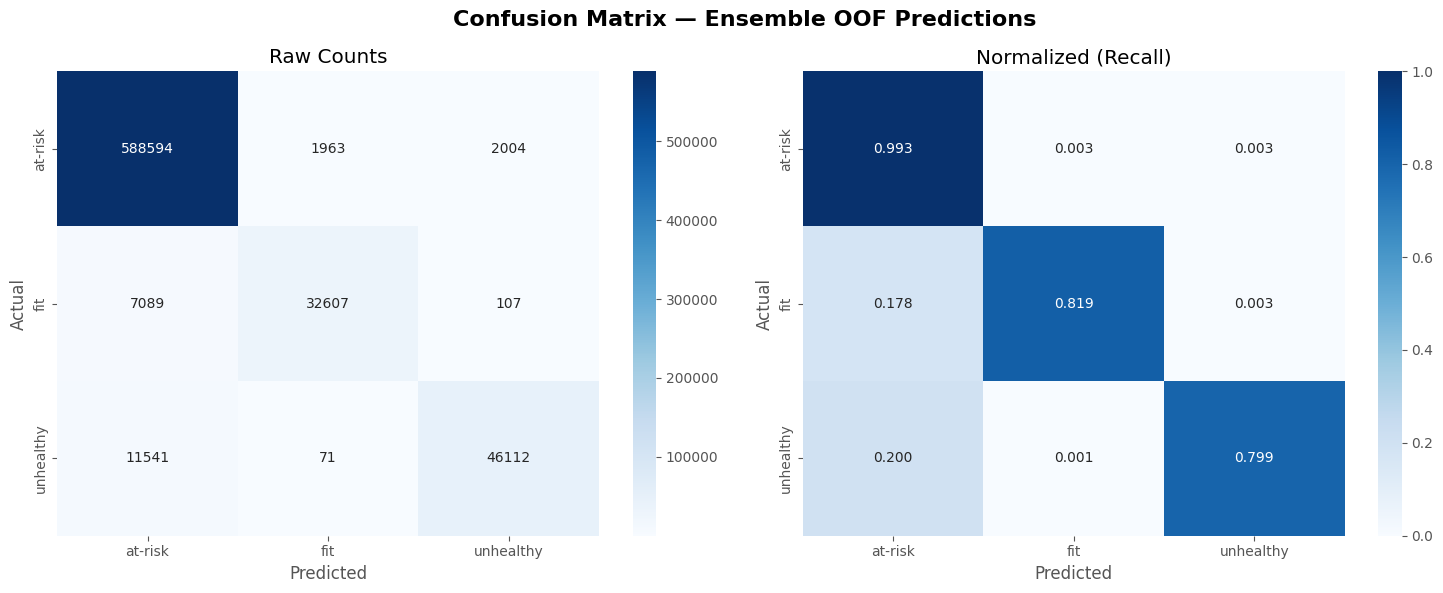

In [15]:
# ==============================================================================
# DIAGNOSTICS & VALIDATION PLOTS
# ==============================================================================
cm = confusion_matrix(y, ens_oof_labels)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Confusion Matrix — Ensemble OOF Predictions', fontsize=16, fontweight='bold')

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names)
axes[0].set_title('Raw Counts')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Blues', ax=axes[1],
            xticklabels=class_names, yticklabels=class_names, vmin=0, vmax=1)
axes[1].set_title('Normalized (Recall)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [16]:
print("📋 Classification Report - Ensemble OOF Predictions:\n")
print(classification_report(y, ens_oof_labels, target_names=class_names, digits=4))

📋 Classification Report - Ensemble OOF Predictions:

              precision    recall  f1-score   support

     at-risk     0.9693    0.9933    0.9812    592561
         fit     0.9413    0.8192    0.8760     39803
   unhealthy     0.9562    0.7988    0.8705     57724

    accuracy                         0.9670    690088
   macro avg     0.9556    0.8705    0.9092    690088
weighted avg     0.9666    0.9670    0.9658    690088



In [17]:
# ==============================================================================
# SUBMISSION GENERATION
# ==============================================================================
submission = pd.DataFrame({
    'id': test['id'],
    'health_condition': le.inverse_transform(ens_test_labels)
})

print("📤 Submission Preview:")
print(submission.head(10))
print(f"\n📦 Shape: {submission.shape}")
print(f"📋 Predictions distribution:\n{submission['health_condition'].value_counts(normalize=True)}")

# Sanity Checks
assert len(submission) == len(sample_sub), "❌ Row count mismatch!"
assert list(submission.columns) == list(sample_sub.columns), "❌ Column mismatch!"
assert submission['health_condition'].isnull().sum() == 0, "❌ Null values found in predictions!"

submission.to_csv('submission.csv', index=False)
print("\n💾 Saved submission.csv successfully!")

📤 Submission Preview:
       id health_condition
0  690088        unhealthy
1  690089          at-risk
2  690090          at-risk
3  690091          at-risk
4  690092        unhealthy
5  690093          at-risk
6  690094          at-risk
7  690095          at-risk
8  690096          at-risk
9  690097          at-risk

📦 Shape: (295753, 2)
📋 Predictions distribution:
health_condition
at-risk      0.881509
unhealthy    0.068740
fit          0.049751
Name: proportion, dtype: float64

💾 Saved submission.csv successfully!
